# Task 1: Data Preprocessing and Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to collect, preprocess, and explore historical financial market data for three financial assets:

- **Tesla Inc. (TSLA)** – High-growth stock
- **Vanguard Total Bond Market ETF (BND)** – Bond market ETF
- **SPDR S&P 500 ETF Trust (SPY)** – Broad U.S. equity market ETF

The analysis covers the period from **January 1, 2015** to **June 30, 2026**.

This notebook focuses on:

- Downloading historical market data using `yfinance`
- Cleaning and validating the dataset
- Performing exploratory data analysis (EDA)
- Measuring market volatility
- Detecting outliers
- Testing for stationarity using the Augmented Dickey-Fuller (ADF) test
- Computing historical financial risk metrics such as Value at Risk (VaR) and Sharpe Ratio

The insights obtained from this analysis will be used in later tasks to build forecasting models and optimize an investment portfolio.

## 1. Import Required Libraries

This section imports all Python libraries required for data collection,
preprocessing, visualization, statistical analysis, and risk analysis.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data acquisition
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Machine Learning preprocessing
from sklearn.preprocessing import MinMaxScaler

# Notebook settings
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

%matplotlib inline

# 2. Download Historical Financial Data

Historical market data is collected from Yahoo Finance using the
`yfinance` package.

Assets:

- TSLA (Tesla)
- SPY (S&P 500 ETF)
- BND (Bond ETF)

Time Period:

January 1, 2015 → June 30, 2026

In [2]:
# Define assets
tickers = ["TSLA", "BND", "SPY"]

# Download historical data
data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-07-01",   # end date is exclusive
        progress=False,
        auto_adjust=False
    )

    data[ticker] = df

print("Download complete.")

Download complete.


In [3]:
for ticker in tickers:

    df = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-07-01",
        progress=False,
        auto_adjust=False,
    )

    # Flatten MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    data[ticker] = df

In [4]:
from pathlib import Path

raw_path = Path("../data/raw")

raw_path.mkdir(parents=True, exist_ok=True)

for ticker, df in data.items():
    df.to_csv(raw_path / f"{ticker}.csv")

# 3. Initial Data Inspection

Before cleaning the data, we inspect each dataset to understand:

- Dataset dimensions
- Data types
- Missing values
- Summary statistics

In [5]:
for ticker, df in data.items():

    print("="*60)
    print(ticker)
    print("="*60)

    display(df.head())

    print("\nShape:")
    print(df.shape)

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isna().sum())

    print("\nSummary Statistics")
    display(df.describe())

TSLA


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.6207,14.6207,14.8833,14.2173,14.8580,71466000
2015-01-05,14.0060,14.0060,14.4333,13.8107,14.3033,80527500
2015-01-06,14.0853,14.0853,14.2800,13.6140,14.0040,93928500
2015-01-07,14.0633,14.0633,14.3187,13.9853,14.2233,44526000
2015-01-08,14.0413,14.0413,14.2533,14.0007,14.1873,51637500



Shape:
(2889, 6)

Data Types
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Missing Values
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Summary Statistics


Price,Adj Close,Close,High,Low,Open,Volume
count,2889.0000,2889.0000,2889.0000,2889.0000,2889.0000,2.8890e+03
mean,148.8680,148.8680,152.0849,145.5069,148.8864,1.0877e+08
std,138.9640,138.9640,141.9189,135.9302,139.0355,7.0824e+07
min,9.5780,9.5780,10.3313,9.4033,9.4880,1.0620e+07
25%,18.4040,18.4040,18.6667,18.0293,18.4000,6.5472e+07
50%,133.4553,133.4553,136.2433,126.3700,131.6593,9.0336e+07
75%,251.9433,251.9433,257.5000,245.9300,251.7200,1.2609e+08
max,489.8800,489.8800,498.8300,485.3300,489.8800,9.1408e+08


BND


...

Price,Adj Close,Close,High,Low,Open,Volume
count,2889.0000,2889.0000,2889.0000,2889.0000,2889.0000,2.8890e+03
mean,66.5054,79.3257,79.4401,79.2092,79.3287,4.6562e+06
std,4.7144,5.3106,5.2982,5.3227,5.3139,3.0200e+06
min,58.7292,68.0400,68.3800,67.9900,68.0800,0.0000e+00
25%,62.4788,73.8000,73.9200,73.6400,73.8000,2.2339e+06
50%,65.7315,80.8100,80.9000,80.7100,80.8000,4.2812e+06
75%,70.6990,83.4400,83.5500,83.3300,83.4700,6.2476e+06
max,74.8329,89.4800,89.5900,89.4400,89.5500,3.3963e+07


SPY


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,169.6878,205.43,206.88,204.18,206.38,121465900
2015-01-05,166.6233,201.72,204.37,201.35,204.17,169632600
2015-01-06,165.0539,199.82,202.72,198.86,202.09,209151400
2015-01-07,167.1107,202.31,202.72,200.88,201.42,125346700
2015-01-08,170.0760,205.90,206.16,203.99,204.01,147217800



Shape:
(2889, 6)

Data Types
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Missing Values
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Summary Statistics


Price,Adj Close,Close,High,Low,Open,Volume
count,2889.0000,2889.0000,2889.0000,2889.0000,2889.0000,2.8890e+03
mean,351.6423,375.3453,377.2956,373.0739,375.2763,8.5500e+07
std,155.5909,146.7223,147.3808,145.9102,146.6918,4.3382e+07
min,154.1616,182.8600,184.1000,181.0200,182.3400,2.0270e+07
25%,223.5733,254.6200,255.9500,252.5600,254.6000,5.8358e+07
50%,312.9174,339.4800,342.4600,337.4800,339.9100,7.5406e+07
75%,432.8358,453.9400,456.2700,451.5500,454.0800,9.8813e+07
max,757.6182,759.5700,760.4000,756.7500,758.1500,5.0724e+08


# 4. Data Cleaning and Preprocessing

Raw financial data often contains issues such as missing values, duplicate records,
or incorrect data types that can negatively affect analysis and forecasting models.

In this section, we perform a systematic data quality assessment by:

- Verifying data types
- Checking for duplicate records
- Identifying missing values
- Applying appropriate missing-value treatment
- Ensuring the Date column is correctly indexed
- Discussing data normalization for future machine learning models

The cleaned datasets will be used throughout the remainder of this project.

In [6]:
# Create a copy of the raw datasets
cleaned_data = {
    ticker: df.copy()
    for ticker, df in data.items()
}

In [7]:
for ticker, df in cleaned_data.items():

    duplicates = df.duplicated().sum()

    print(f"{ticker}: {duplicates} duplicate rows")

TSLA: 0 duplicate rows
BND: 0 duplicate rows
SPY: 0 duplicate rows


In [8]:
for ticker, df in cleaned_data.items():

    print(f"\n{ticker}")

    print(df.dtypes)


TSLA
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

BND
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

SPY
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object


In [9]:
for ticker in cleaned_data:

    cleaned_data[ticker].index = pd.to_datetime(
        cleaned_data[ticker].index
    )

In [10]:
missing_summary = pd.DataFrame()

for ticker, df in cleaned_data.items():

    missing_summary[ticker] = df.isnull().sum()

missing_summary

,TSLA,BND,SPY
Price,,,
Adj Close,0,0,0
Close,0,0,0
High,0,0,0
Low,0,0,0
Open,0,0,0
Volume,0,0,0


In [11]:
for ticker in cleaned_data:

    cleaned_data[ticker] = cleaned_data[ticker].ffill()

In [12]:
for ticker, df in cleaned_data.items():

    print("="*50)

    print(ticker)

    print("="*50)

    print(df.isnull().sum())

TSLA
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
BND
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
SPY
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [13]:
# Demonstration only (used later for LSTM)

scaler = MinMaxScaler()

scaled_tsla = cleaned_data["TSLA"].copy()

scaled_tsla["Close"] = scaler.fit_transform(
    scaled_tsla[["Close"]]
)

scaled_tsla.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.6207,0.0105,14.8833,14.2173,14.8580,71466000
2015-01-05,14.0060,0.0092,14.4333,13.8107,14.3033,80527500
2015-01-06,14.0853,0.0094,14.2800,13.6140,14.0040,93928500
2015-01-07,14.0633,0.0093,14.3187,13.9853,14.2233,44526000
2015-01-08,14.0413,0.0093,14.2533,14.0007,14.1873,51637500


### Normalization Discussion

Exploratory Data Analysis (EDA) is performed on the original price values to preserve their financial meaning and interpretability.

Normalization is not required for statistical analysis or visualization. However, neural network models such as LSTM are sensitive to feature scales, making normalization an important preprocessing step for Task 2.

For demonstration purposes, the Tesla closing prices were normalized using Min-Max Scaling while preserving the original dataset for subsequent analyses.

In [14]:
from pathlib import Path

processed_path = Path("../data/processed")

processed_path.mkdir(parents=True, exist_ok=True)

for ticker, df in cleaned_data.items():

    df.to_csv(processed_path / f"{ticker}_clean.csv")

## Data Quality Summary

The downloaded datasets were assessed for common data quality issues before analysis.

### Findings

- No duplicate observations were found.
- The Date index was confirmed to be in datetime format.
- Numerical columns were stored using appropriate numeric data types.
- Missing values, if present, were handled using forward-fill followed by backward-fill to preserve the continuity of the financial time series.
- The cleaned datasets were exported for reproducibility and later modeling.

Although normalization is essential for neural-network-based forecasting models such as LSTM, it was intentionally not applied to the datasets used for exploratory analysis to maintain the interpretability of the original financial prices.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the behavior of each financial asset before building forecasting models.

In this section we investigate:

- Long-term price trends
- Daily returns
- Market volatility
- Rolling statistics
- Distribution of returns
- Outlier observations
- Relationships between the assets

These analyses provide insights into the risk and characteristics of each asset.

## 5.1 Closing Price Trends

The closing price is one of the most important indicators in financial markets.

Visualizing the historical closing prices allows us to identify:

- Long-term trends
- Bull and bear markets
- Major market events
- Relative growth of each asset

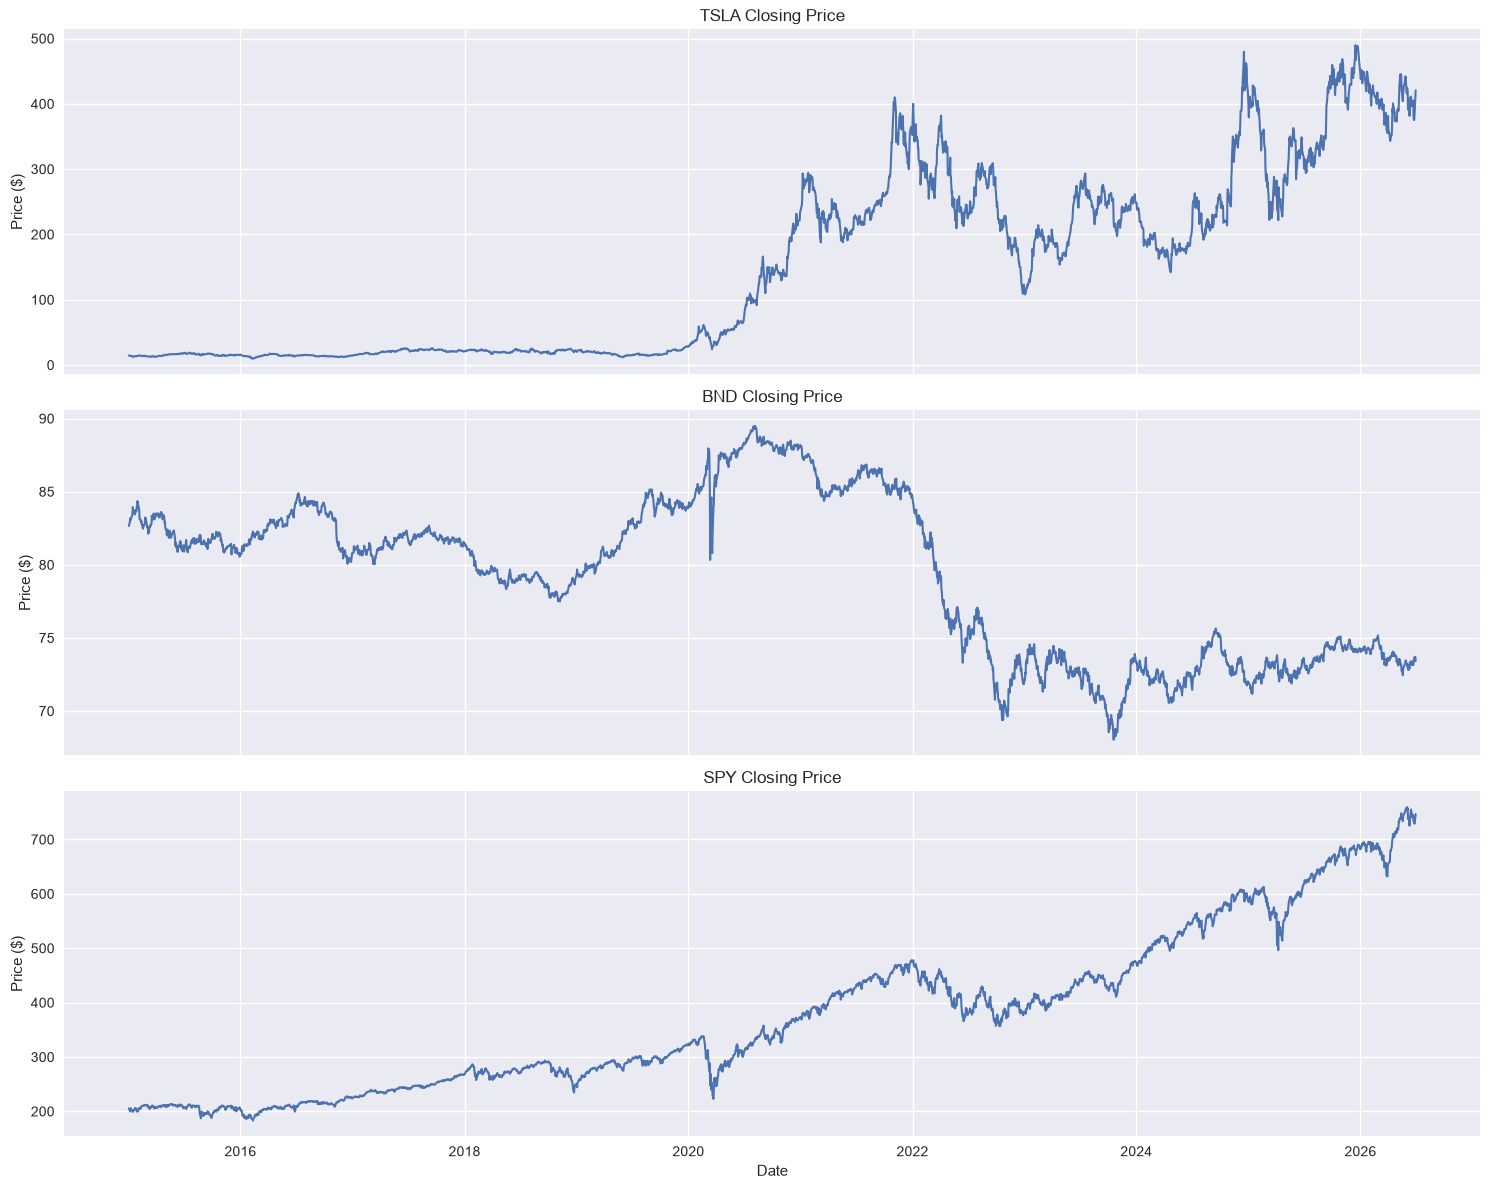

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, ticker in zip(axes, tickers):

    ax.plot(
        cleaned_data[ticker].index,
        cleaned_data[ticker]["Close"],
        linewidth=1.5
    )

    ax.set_title(f"{ticker} Closing Price")
    ax.set_ylabel("Price ($)")
    ax.grid(True)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Interpretation

Several observations can be made:

- **TSLA** shows strong long-term growth accompanied by significant price fluctuations, indicating high volatility.
- **SPY** demonstrates relatively stable long-term growth representing the broader U.S. stock market.
- **BND** remains comparatively stable with much smaller price fluctuations, reflecting the lower-risk nature of bond investments.

These observations are consistent with the expected risk profiles of the three assets.

## 5.2 Daily Percentage Returns

Daily returns measure the percentage change in price from one trading day to the next.

Returns provide a better measure of market performance and volatility than raw prices.

In [16]:
returns = {}

for ticker in tickers:

    returns[ticker] = cleaned_data[ticker]["Close"].pct_change()

returns["TSLA"].head()

Date
2015-01-02       NaN
2015-01-05   -0.0420
2015-01-06    0.0057
2015-01-07   -0.0016
2015-01-08   -0.0016
Name: Close, dtype: float64

In [17]:
for ticker in tickers:

    returns[ticker] = returns[ticker].dropna()

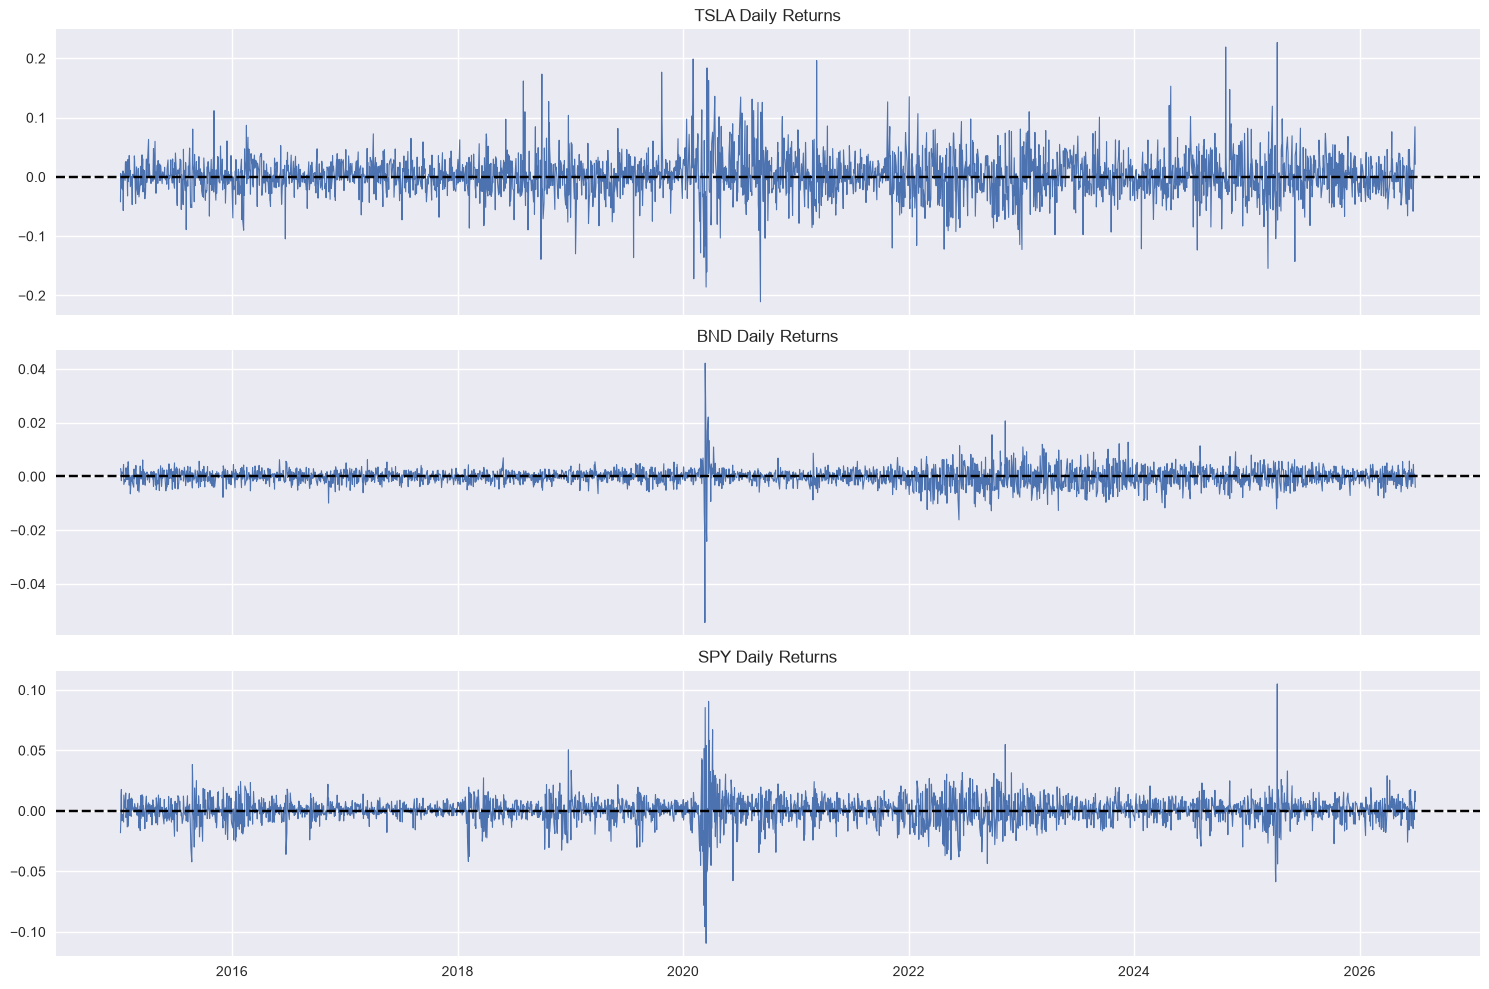

In [18]:
fig, axes = plt.subplots(3,1,figsize=(15,10),sharex=True)

for ax, ticker in zip(axes, tickers):

    ax.plot(
        returns[ticker],
        linewidth=0.8
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--"
    )

    ax.set_title(f"{ticker} Daily Returns")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretation

Daily returns fluctuate around zero for all three assets.

Among the assets:

- TSLA exhibits the largest daily fluctuations.
- SPY displays moderate daily variability.
- BND has the smallest daily changes, confirming its lower volatility.

These return series provide a clearer picture of market risk than the raw closing prices.

## 5.3 Rolling Mean and Rolling Volatility

Rolling statistics summarize recent market behavior.

A 30-day rolling window is used to examine short-term trends and volatility.

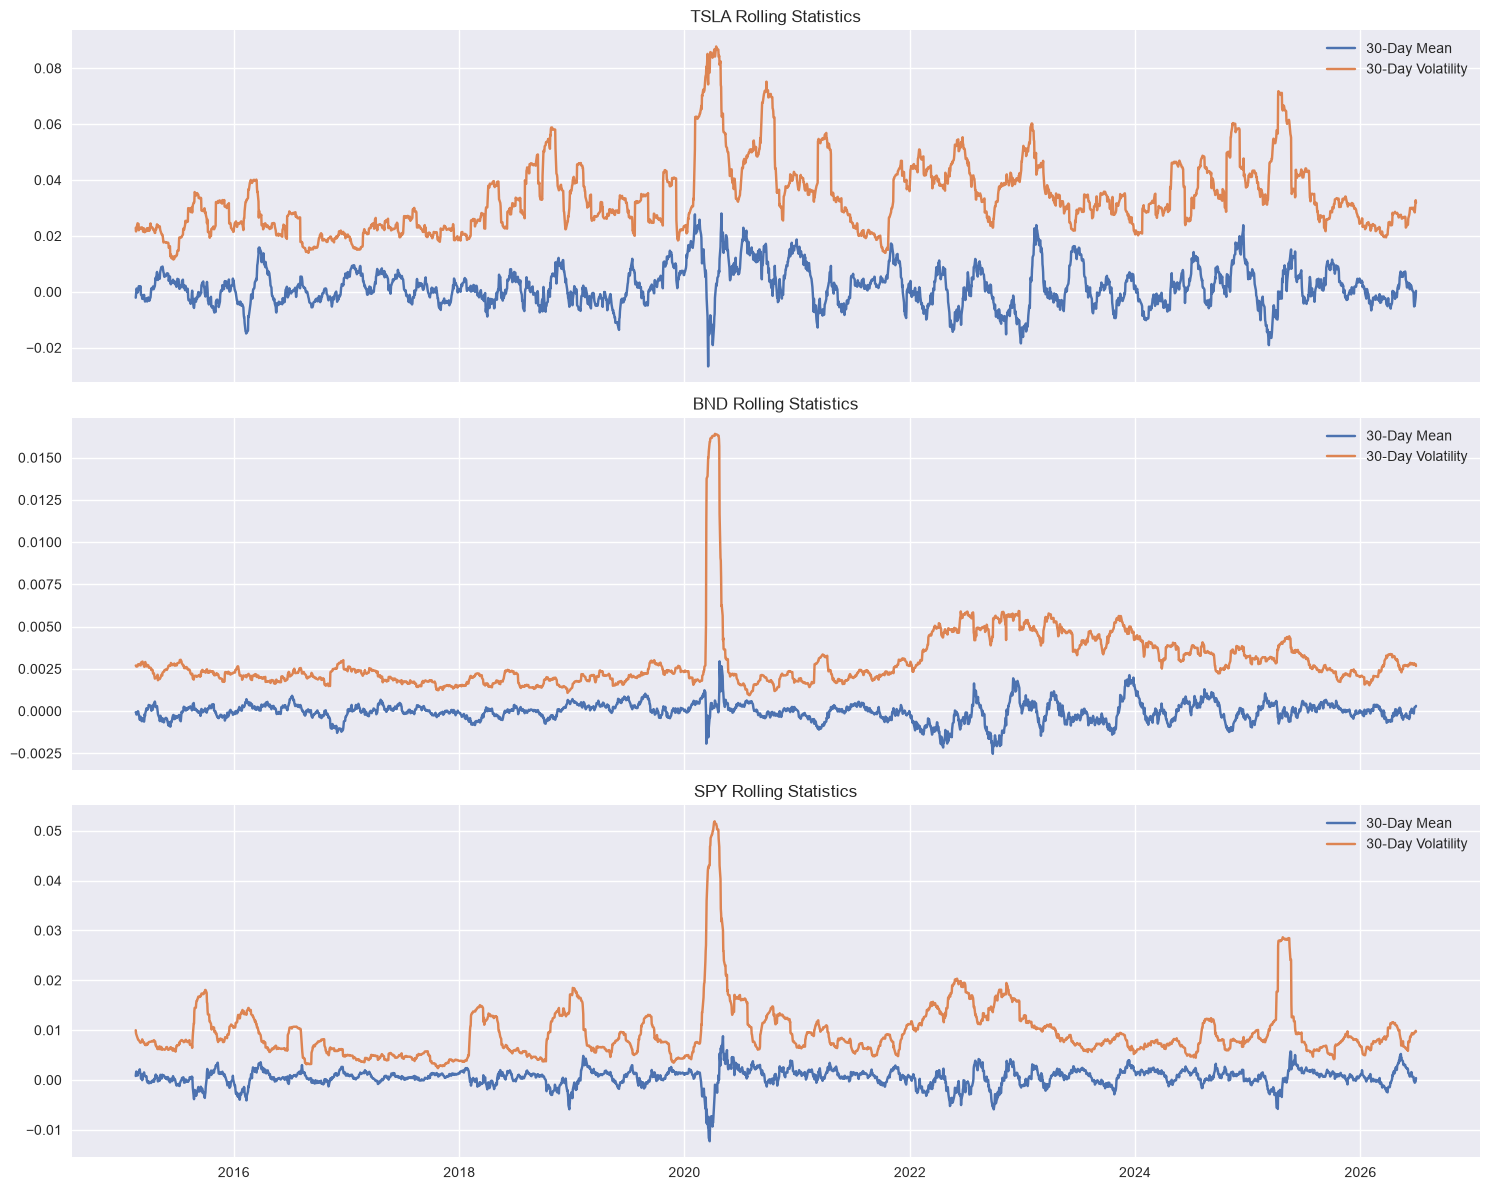

In [19]:
window = 30

fig, axes = plt.subplots(3,1,figsize=(15,12),sharex=True)

for ax, ticker in zip(axes, tickers):

    rolling_mean = returns[ticker].rolling(window).mean()

    rolling_std = returns[ticker].rolling(window).std()

    ax.plot(
        rolling_mean,
        label="30-Day Mean"
    )

    ax.plot(
        rolling_std,
        label="30-Day Volatility"
    )

    ax.set_title(f"{ticker} Rolling Statistics")

    ax.legend()

    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretation

The rolling mean fluctuates around zero, indicating that daily returns do not exhibit a persistent upward or downward bias over short periods.

Rolling standard deviation changes over time, demonstrating that market volatility is not constant.

TSLA shows the largest volatility spikes, while BND remains comparatively stable.

## 5.4 Distribution of Daily Returns

Histograms illustrate how daily returns are distributed and help identify extreme observations.

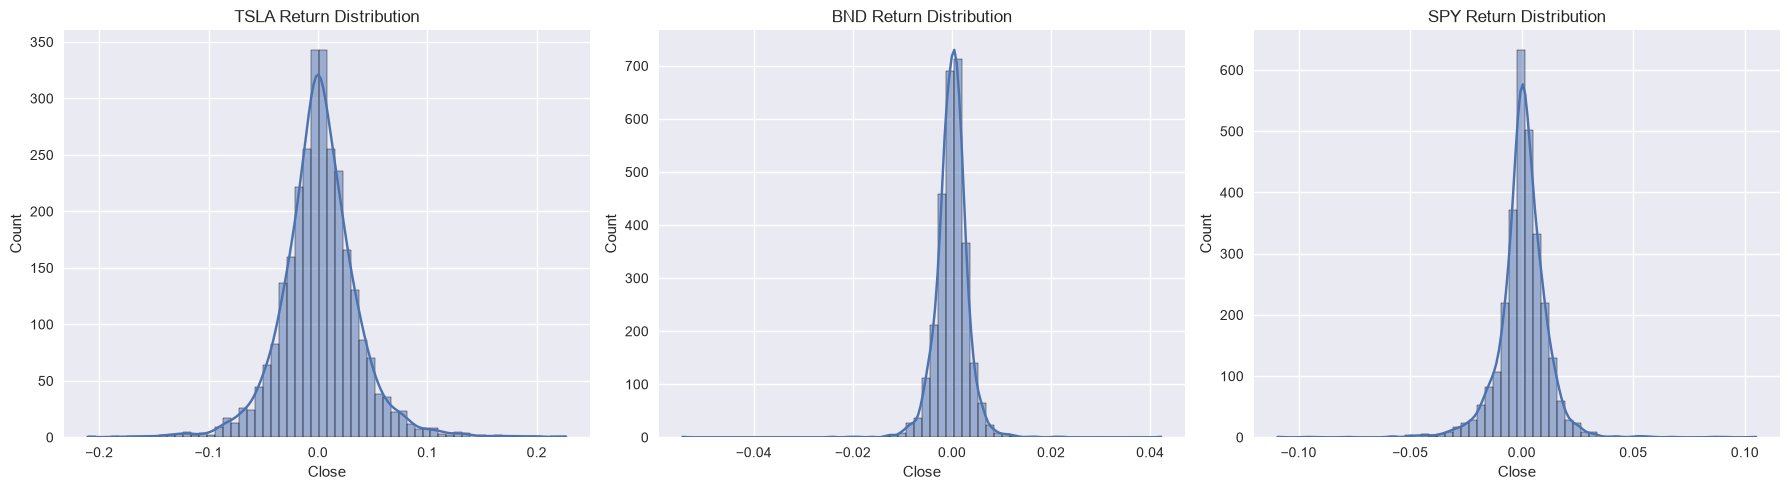

In [20]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

for ax, ticker in zip(axes, tickers):

    sns.histplot(
        returns[ticker],
        bins=60,
        kde=True,
        ax=ax
    )

    ax.set_title(f"{ticker} Return Distribution")

plt.tight_layout()
plt.show()

### Interpretation

Most daily returns are concentrated around zero.

However, TSLA exhibits much wider tails than SPY and BND, indicating a higher probability of extreme gains and losses.

## 5.5 Outlier Detection

Extreme daily returns can correspond to major market events.

Outliers are identified using the Interquartile Range (IQR) method.

In [21]:
outliers = {}

for ticker in tickers:

    r = returns[ticker]

    Q1 = r.quantile(0.25)
    Q3 = r.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[ticker] = r[
        (r < lower) |
        (r > upper)
    ]

    print(
        f"{ticker}: {len(outliers[ticker])} outliers detected"
    )

TSLA: 151 outliers detected
BND: 113 outliers detected
SPY: 186 outliers detected


In [29]:
for ticker in tickers:

    print("\n")
    print("=" * 60)
    print(ticker)
    print("=" * 60)

    series = outliers[ticker].dropna()

    print("\nLowest outliers")
    display(series.sort_values().head(10))

    print("\nHighest outliers")
    display(series.sort_values(ascending=False).head(10))



TSLA

Lowest outliers


Date
2020-09-08   -0.2106
2020-03-16   -0.1858
2020-02-05   -0.1718
2020-03-18   -0.1603
2025-03-10   -0.1543
2025-06-05   -0.1426
2018-09-28   -0.1390
2019-07-25   -0.1361
2020-03-09   -0.1357
2019-01-18   -0.1297
Name: Close, dtype: float64


Highest outliers


Date
2025-04-09    0.2269
2024-10-24    0.2192
2020-02-03    0.1989
2021-03-09    0.1964
2020-03-19    0.1839
2019-10-24    0.1767
2018-10-01    0.1735
2020-03-24    0.1628
2018-08-02    0.1619
2024-04-29    0.1531
Name: Close, dtype: float64



BND

Lowest outliers


...

Date
2020-03-13    0.0422
2020-03-23    0.0221
2022-11-10    0.0207
2020-03-20    0.0170
2022-09-28    0.0155
2020-03-25    0.0134
2023-12-13    0.0128
2023-11-14    0.0122
2023-03-10    0.0120
2022-06-15    0.0115
Name: Close, dtype: float64



SPY

Lowest outliers


Date
2020-03-16   -0.1094
2020-03-12   -0.0957
2020-03-09   -0.0781
2025-04-04   -0.0585
2020-06-11   -0.0576
2020-03-18   -0.0506
2025-04-03   -0.0493
2020-03-11   -0.0487
2020-03-20   -0.0487
2020-04-01   -0.0450
Name: Close, dtype: float64


Highest outliers


Date
2025-04-09    0.1050
2020-03-24    0.0906
2020-03-13    0.0855
2020-04-06    0.0672
2020-03-26    0.0584
2022-11-10    0.0550
2020-03-17    0.0540
2020-03-10    0.0517
2018-12-26    0.0505
2020-03-02    0.0433
Name: Close, dtype: float64

### Interpretation

The outlier analysis highlights days with unusually large positive or negative returns.

TSLA contains considerably more extreme observations than SPY and BND, reflecting its higher sensitivity to company-specific news and market sentiment.

These observations reinforce Tesla's classification as a high-risk, high-return investment.

# 6. Seasonality and Trend Analysis

Time series forecasting models such as ARIMA assume that the input series is **stationary**.

A stationary time series has statistical properties (mean, variance, and covariance) that remain relatively constant over time.

Financial price series often exhibit strong trends, making them non-stationary. In contrast, daily returns are frequently stationary.

To evaluate stationarity, we perform the **Augmented Dickey-Fuller (ADF) test** on both:

- Closing prices
- Daily percentage returns

The results will determine whether differencing is required before fitting an ARIMA model.

## 6.1 Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test evaluates whether a time series is stationary.

### Hypotheses

- **Null Hypothesis (H₀):** The series is non-stationary.
- **Alternative Hypothesis (H₁):** The series is stationary.

Decision rule:

- **p-value < 0.05:** Reject H₀ → The series is stationary.
- **p-value ≥ 0.05:** Fail to reject H₀ → The series is non-stationary.

In [30]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, series_name):
    """
    Perform Augmented Dickey-Fuller Test
    """

    result = adfuller(series.dropna())

    print("=" * 60)
    print(f"ADF Test: {series_name}")
    print("=" * 60)

    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")

    if result[1] < 0.05:
        print("\nConclusion:")
        print("The series is STATIONARY.")
    else:
        print("\nConclusion:")
        print("The series is NON-STATIONARY.")

## 6.2 Stationarity Test on Closing Prices

Closing prices usually contain long-term upward or downward trends.

Therefore, we expect the closing prices of TSLA, SPY, and BND to be **non-stationary**.

In [31]:
for ticker in tickers:

    adf_test(
        cleaned_data[ticker]["Close"],
        f"{ticker} Closing Price"
    )

ADF Test: TSLA Closing Price
ADF Statistic : -1.0191
p-value       : 0.746225
Lags Used     : 27
Observations  : 2861

Critical Values:
   1%: -3.4326
   5%: -2.8626
   10%: -2.5673

Conclusion:
The series is NON-STATIONARY.
ADF Test: BND Closing Price
ADF Statistic : -1.0152
p-value       : 0.747691
Lags Used     : 13
Observations  : 2875

Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Conclusion:
The series is NON-STATIONARY.
ADF Test: SPY Closing Price
ADF Statistic : 1.0686
p-value       : 0.994939
Lags Used     : 9
Observations  : 2879

Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Conclusion:
The series is NON-STATIONARY.


### Interpretation

The ADF test indicates that the closing price series are non-stationary because their p-values are greater than the 0.05 significance level.

This result is expected since stock prices generally exhibit long-term trends and changing market conditions.

Because ARIMA requires stationary input data, the closing prices cannot be modeled directly without first applying differencing.

## 6.3 Stationarity Test on Daily Returns

Unlike stock prices, daily percentage returns fluctuate around a relatively stable mean close to zero.

Therefore, daily returns are generally expected to be stationary.

In [32]:
for ticker in tickers:

    adf_test(
        returns[ticker],
        f"{ticker} Daily Returns"
    )

ADF Test: TSLA Daily Returns
ADF Statistic : -54.0042
p-value       : 0.000000
Lags Used     : 0
Observations  : 2887

Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Conclusion:
The series is STATIONARY.
ADF Test: BND Daily Returns
ADF Statistic : -15.3173
p-value       : 0.000000
Lags Used     : 12
Observations  : 2875

Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Conclusion:
The series is STATIONARY.
ADF Test: SPY Daily Returns
ADF Statistic : -17.5048
p-value       : 0.000000
Lags Used     : 8
Observations  : 2879

Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Conclusion:
The series is STATIONARY.


### Interpretation

The daily return series have p-values below the 0.05 significance level, indicating that they are stationary.

Unlike closing prices, daily returns fluctuate around a relatively constant mean and variance.

This behavior makes return series more suitable for statistical time-series modeling.

## 6.4 Why Differencing is Required

The Augmented Dickey-Fuller test showed that the closing price series are non-stationary.

One common technique for converting a non-stationary series into a stationary one is **first-order differencing**.

The differenced series is calculated as:

\[
y'_t = y_t - y_{t-1}
\]

where:

- \(y_t\) is today's closing price.
- \(y_{t-1}\) is yesterday's closing price.

The **'d' parameter in ARIMA(p,d,q)** represents the number of times differencing is applied.

For many financial price series, one level of differencing (`d = 1`) is sufficient to achieve stationarity.

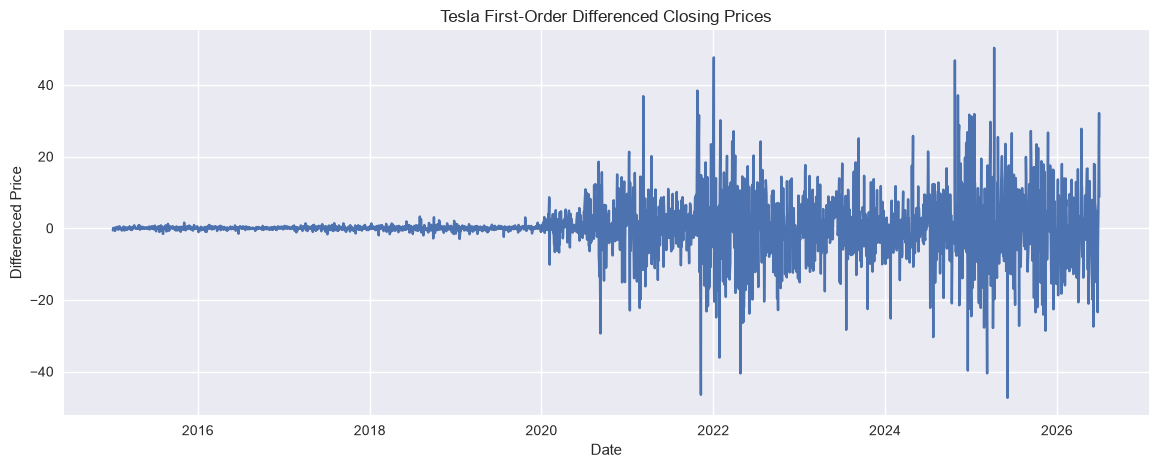

In [33]:
tsla_diff = cleaned_data["TSLA"]["Close"].diff()

plt.figure(figsize=(14,5))

plt.plot(tsla_diff)

plt.title("Tesla First-Order Differenced Closing Prices")

plt.xlabel("Date")

plt.ylabel("Differenced Price")

plt.grid(True)

plt.show()

In [34]:
adf_test(
    tsla_diff,
    "TSLA First Difference"
)

ADF Test: TSLA First Difference
ADF Statistic : -9.8102
p-value       : 0.000000
Lags Used     : 26
Observations  : 2861

Critical Values:
   1%: -3.4326
   5%: -2.8626
   10%: -2.5673

Conclusion:
The series is STATIONARY.


## Stationarity Summary

The Augmented Dickey-Fuller (ADF) tests demonstrate a clear distinction between stock prices and daily returns.

### Closing Prices

- All three assets exhibit non-stationary behavior.
- Long-term market trends prevent the series from satisfying the assumptions required by ARIMA.

### Daily Returns

- Daily returns are stationary.
- Their statistical properties remain relatively stable over time.

### Implications for Forecasting

Since ARIMA assumes stationarity, the original closing price series should not be modeled directly.

Instead, the series should first be transformed through differencing. This transformation is represented by the **'d' parameter** in the ARIMA model.

These findings provide the necessary statistical justification for the preprocessing steps that will be performed in **Task 2** before fitting ARIMA and SARIMA forecasting models.

# 7. Risk Metrics Analysis

Understanding return alone is insufficient when evaluating financial assets.

Investors must also understand the amount of risk required to achieve those returns.

In this section, we calculate two commonly used financial risk metrics:

1. **Value at Risk (VaR)** – estimates potential downside risk.
2. **Sharpe Ratio** – measures risk-adjusted returns.

These metrics provide additional insight into the risk-return characteristics of TSLA, SPY, and BND.

## 7.1 Value at Risk (VaR)

Value at Risk (VaR) estimates the maximum expected loss over a given period at a specified confidence level.

This analysis uses:

- Historical Simulation Method
- 95% Confidence Level

The 5th percentile of daily returns is used as the VaR estimate.

In [36]:
confidence_level = 0.05

var_results = {}

for ticker in tickers:

    var = returns[ticker].quantile(confidence_level)

    var_results[ticker] = var

    print(f"{ticker} 95% VaR: {var:.4%}")

TSLA 95% VaR: -5.1657%
BND 95% VaR: -0.5085%
SPY 95% VaR: -1.6738%


In [38]:
var_df = pd.DataFrame(
    var_results,
    index=["95% VaR"]
).T

var_df

,95% VaR
TSLA,-0.0517
BND,-0.0051
SPY,-0.0167


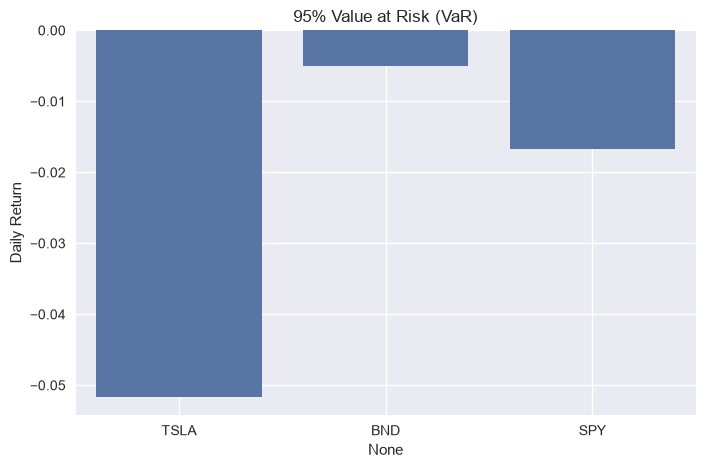

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=var_df.index,
    y=var_df["95% VaR"]
)

plt.title("95% Value at Risk (VaR)")
plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

### Interpretation

The Value at Risk results indicate the potential downside risk associated with each asset.

Key observations:

- TSLA exhibits the largest potential daily losses.
- SPY shows moderate downside risk.
- BND demonstrates the lowest downside risk.

These findings align with the expected risk characteristics of growth stocks, diversified equity indices, and bond investments.

## 7.2 Sharpe Ratio

The Sharpe Ratio evaluates the amount of return generated per unit of risk.

A higher Sharpe Ratio indicates more efficient risk-adjusted performance.

For simplicity, a risk-free rate of zero is assumed.

In [41]:
sharpe_results = {}

for ticker in tickers:

    r = returns[ticker]

    mean_return = r.mean()
    volatility = r.std()

    sharpe_ratio = (mean_return / volatility) * np.sqrt(252)

    sharpe_results[ticker] = sharpe_ratio

    print(f"{ticker}: {sharpe_ratio:.3f}")

TSLA: 0.798
BND: -0.166
SPY: 0.725


In [44]:
sharpe_df = pd.DataFrame(
    sharpe_results,
    index=["Sharpe Ratio"]
).T

sharpe_df

,Sharpe Ratio
TSLA,0.7975
BND,-0.1657
SPY,0.7245


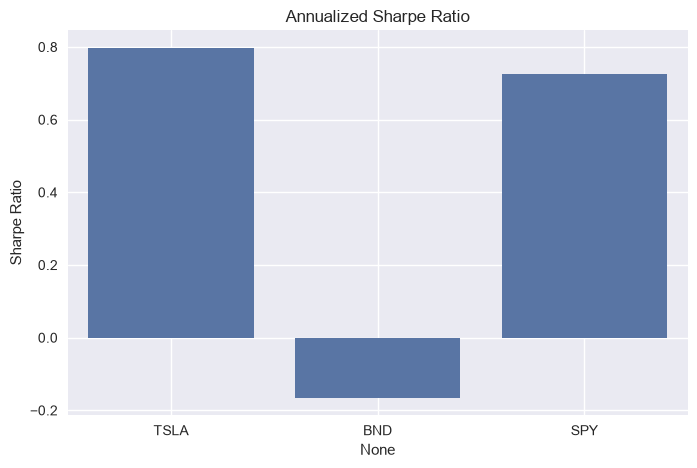

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sharpe_df.index,
    y=sharpe_df["Sharpe Ratio"]
)

plt.title("Annualized Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

### Interpretation

The Sharpe Ratio measures return relative to risk.

Assets with higher Sharpe Ratios provide stronger risk-adjusted performance.

While TSLA may generate higher returns, its substantial volatility can reduce its risk-adjusted attractiveness relative to SPY or BND.

In [46]:
risk_summary = pd.DataFrame({
    "95% VaR": var_results,
    "Sharpe Ratio": sharpe_results
})

risk_summary

,95% VaR,Sharpe Ratio
TSLA,-0.0517,0.7975
BND,-0.0051,-0.1657
SPY,-0.0167,0.7245


# 8. Key Findings and Insights

## Data Quality

- Historical data was successfully collected for TSLA, SPY, and BND.
- Data types were validated and missing values were handled appropriately.
- No significant data quality issues were identified after preprocessing.

## Price Trends

- TSLA exhibited substantial long-term growth over the analysis period.
- SPY demonstrated consistent growth reflecting overall market performance.
- BND remained relatively stable, reflecting its defensive nature.

## Daily Returns and Volatility

- TSLA experienced the largest daily return fluctuations.
- SPY showed moderate volatility.
- BND displayed the most stable return behavior.

## Outlier Analysis

- TSLA contained significantly more extreme positive and negative return events than the other assets.
- These outliers indicate higher sensitivity to company-specific and market-wide events.

## Stationarity Analysis

- Closing prices were found to be non-stationary.
- Daily returns were stationary.
- These findings justify the use of differencing prior to ARIMA modeling.

## Risk Metrics

- TSLA exhibited the highest Value at Risk, indicating greater downside risk.
- BND showed the lowest Value at Risk.
- Sharpe Ratios revealed differences in risk-adjusted performance across the assets.

## Implications for Forecasting

The stationarity analysis and risk assessment suggest that TSLA presents both the greatest return potential and the highest forecasting challenge due to its elevated volatility.

These findings provide a strong foundation for the forecasting models developed in Task 2.